<a href="https://colab.research.google.com/github/abheer2005/Machine-Learning-Projects/blob/main/naivebayesclassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [ ]:
target=df.Survived
inputs=df.drop('Survived',axis='columns')

In [ ]:
dummies=pd.get_dummies(inputs.Sex)
dummies = pd.get_dummies(inputs.Sex).astype(int)
dummies.head(3)

,female,male
0,0,1
1,1,0
2,1,0


In [ ]:
inputs=pd.concat([inputs,dummies],axis='columns')
inputs.head(3)

,Pclass,Sex,Age,Fare,female,male,female,male
0,3,male,22.0,7.2500,0,1,0,1
1,1,female,38.0,71.2833,1,0,1,0
2,3,female,26.0,7.9250,1,0,1,0


In [ ]:
inputs.drop('Sex',axis='columns',inplace=True)
inputs.head(3)

,Pclass,Age,Fare,female,male,female,male
0,3,22.0,7.2500,0,1,0,1
1,1,38.0,71.2833,1,0,1,0
2,3,26.0,7.9250,1,0,1,0


In [ ]:
inputs.columns[inputs.isna().any()]

Index(['Age'], dtype='object')

In [ ]:
inputs.Age[:10]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
5,NaN
6,54.0
7,2.0
8,27.0
9,14.0


In [ ]:
inputs.Age=inputs.Age.fillna(inputs.Age.mean())
inputs.head()

,Pclass,Age,Fare,female,male,female,male
0,3,22.0,7.2500,0,1,0,1
1,1,38.0,71.2833,1,0,1,0
2,3,26.0,7.9250,1,0,1,0
3,1,35.0,53.1000,1,0,1,0
4,3,35.0,8.0500,0,1,0,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(inputs,target,test_size=0.2)

In [ ]:
len(X_train)

712

In [ ]:
len(inputs)

891

In [ ]:
len(X_test)

179

In [ ]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()

In [ ]:
model.fit(X_train,Y_train)

GaussianNB()

In [ ]:
model.score(X_test,Y_test)

0.776536312849162

In [ ]:
X_test[:10]

,Pclass,Age,Fare,female,male,female,male
489,3,9.000000,15.9000,0,1,0,1
403,3,28.000000,15.8500,0,1,0,1
650,3,29.699118,7.8958,0,1,0,1
466,2,29.699118,0.0000,0,1,0,1
557,1,29.699118,227.5250,0,1,0,1
373,1,22.000000,135.6333,0,1,0,1
92,1,46.000000,61.1750,0,1,0,1
345,2,24.000000,13.0000,1,0,1,0
868,3,29.699118,9.5000,0,1,0,1
701,1,35.000000,26.2875,0,1,0,1


In [ ]:
Y_test[:10]

,Survived
489,1
403,0
650,0
466,0
557,0
373,0
92,0
345,1
868,0
701,1


In [ ]:
model.predict(X_test[:10])

array([0, 0, 0, 0, 1, 1, 0, 1, 0, 0])

In [ ]:
model.predict_proba(X_test[:10])

array([[9.98777156e-01, 1.22284426e-03],
       [9.99325418e-01, 6.74582375e-04],
       [9.99325478e-01, 6.74522446e-04],
       [9.98368788e-01, 1.63121234e-03],
       [4.18188658e-08, 9.99999958e-01],
       [1.13991210e-01, 8.86008790e-01],
       [9.87130481e-01, 1.28695190e-02],
       [4.35607472e-04, 9.99564393e-01],
       [9.99333107e-01, 6.66892561e-04],
       [9.94831313e-01, 5.16868707e-03]])

***CONFUSION MATRIX TO SEE WHERE IT FAILED ***

In [ ]:
Y_predicted=model.predict(X_test)
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,Y_predicted)
cm

array([[94, 16],
       [24, 45]])

Text(95.72222222222221, 0.5, 'Truth')

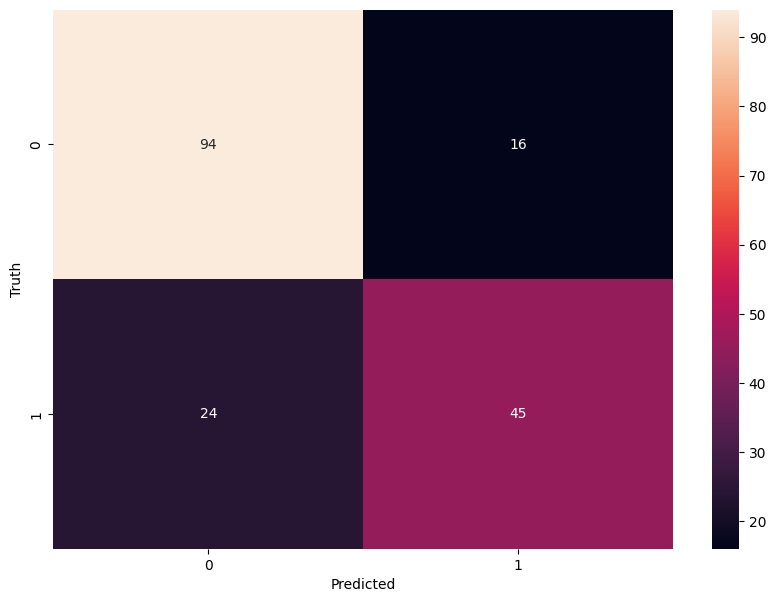

In [ ]:
import seaborn as sn
from matplotlib import pyplot as plt
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")

**NaiveBayes2detectspamemail**

In [ ]:
dd=pd.read_csv("spamnaivebayes.csv")
dd.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
dd.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [ ]:
dd['spam']=dd['Category'].apply(lambda x: 1 if x=='spam' else 0)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(dd.Message,dd.spam,test_size=0.25)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
v=CountVectorizer()
X_train_count=v.fit_transform(X_train.values)
X_train_count.toarray()[:3]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train_count,Y_train)

MultinomialNB()

In [ ]:
emails=[
    'Hey mohan, can we get together to watch football game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]
emails_count=v.transform(emails)
model.predict(emails_count)

array([0, 1])

In [ ]:
X_test_count=v.transform(X_test)
model.score(X_test_count,Y_test)

0.9856424982053122

In [ ]:
from sklearn.pipeline import Pipeline
clf=Pipeline([
    ('vectorizer',CountVectorizer()),
    ('nb',MultinomialNB())
])

In [ ]:
clf.fit(X_train,Y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [ ]:
clf.score(X_test,Y_test)

0.9856424982053122

**EXERCISE OF WINE DATASET TO CLASSIFY THEM IN # CATEGORIES USE GAUSSIAN AND MULTINOMIAL CLASSIFIER AND SEE WHICH PERFORMS BETTER**

In [ ]:
from sklearn.datasets import load_wine

In [ ]:
wine=load_wine()

In [ ]:
dir(wine)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [ ]:
wine.data[:2]

array([[1.423e+01, 1.710e+00, 2.430e+00, 1.560e+01, 1.270e+02, 2.800e+00,
        3.060e+00, 2.800e-01, 2.290e+00, 5.640e+00, 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, 1.120e+01, 1.000e+02, 2.650e+00,
        2.760e+00, 2.600e-01, 1.280e+00, 4.380e+00, 1.050e+00, 3.400e+00,
        1.050e+03]])

In [ ]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [ ]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [ ]:
wine.target[0:2]

array([0, 0])

In [ ]:
d = pd.DataFrame(wine.data,columns=wine.feature_names)
d.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
d['target'] = wine.target
d[50:70]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
50,13.05,1.73,2.04,12.4,92.0,2.72,3.27,0.17,2.91,7.20,1.12,2.91,1150.0,0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0,0
52,13.82,1.75,2.42,14.0,111.0,3.88,3.74,0.32,1.87,7.05,1.01,3.26,1190.0,0
53,13.77,1.90,2.68,17.1,115.0,3.00,2.79,0.39,1.68,6.30,1.13,2.93,1375.0,0
54,13.74,1.67,2.25,16.4,118.0,2.60,2.90,0.21,1.62,5.85,0.92,3.20,1060.0,0
55,13.56,1.73,2.46,20.5,116.0,2.96,2.78,0.20,2.45,6.25,0.98,3.03,1120.0,0
56,14.22,1.70,2.30,16.3,118.0,3.20,3.00,0.26,2.03,6.38,0.94,3.31,970.0,0
57,13.29,1.97,2.68,16.8,102.0,3.00,3.23,0.31,1.66,6.00,1.07,2.84,1270.0,0
58,13.72,1.43,2.50,16.7,108.0,3.40,3.67,0.19,2.04,6.80,0.89,2.87,1285.0,0
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.3, random_state=100)

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
model = GaussianNB()
model.fit(X_train,y_train)

GaussianNB()

In [ ]:
model.score(X_test,y_test)

1.0

In [ ]:
mn = MultinomialNB()
mn.fit(X_train,y_train)
mn.score(X_test,y_test)

0.7777777777777778